In [ ]:
# %pip install torch torchvision torchaudio --quiet
# %pip install diffusers transformers accelerate einops opencv-python tqdm --quiet

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2 # type: ignore
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
from diffusers import AutoencoderKL # type: ignore
from transformers import CLIPProcessor, CLIPModel

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
def load_video(path, size=256, max_frames=16):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        raise ValueError("❌ Cannot open video file")

    frames = []

    while cap.isOpened() and len(frames) < max_frames:
        ret, frame = cap.read()

        if not ret or frame is None:
            break

        frame = cv2.resize(frame, (size, size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise ValueError("❌ No frames loaded from video")

    print(f"Loaded {len(frames)} frames")

    return np.array(frames)

In [ ]:
def encode_frames(frames):
    frames = torch.tensor(frames).float() / 255.0
    frames = frames.permute(0, 3, 1, 2).to(device)

    with torch.no_grad():
        latents = vae.encode(frames).latent_dist.sample()

    return latents * 0.18215

In [ ]:
def decode_latents(latents):
    with torch.no_grad():
        imgs = vae.decode(latents / 0.18215).sample

    imgs = (imgs.clamp(-1, 1) + 1) / 2
    return imgs

In [ ]:
class DriftNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(4, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 4, 3, padding=1)
        )

    def forward(self, x, t):
        return self.net(x)

driftnet = DriftNet().to(device)

In [ ]:
def sample_path(x0, x1, t):
    noise = torch.randn_like(x0)
    return (1 - t) * x0 + t * x1 + 0.1 * noise

In [ ]:
def clip_loss(images, text):
    images = F.interpolate(images, size=224)

    inputs = clip_processor(
        text=[text],
        images=[img.cpu() for img in images],
        return_tensors="pt",
        padding=True
    ).to(device)

    outputs = clip_model(**inputs)

    image_emb = outputs.image_embeds
    text_emb = outputs.text_embeds

    return ((image_emb - text_emb) ** 2).mean()

In [ ]:
def soft_sb_loss(model, x0, x1, text, lambda_weight=0.5):
    t = torch.rand(x0.size(0), 1, 1, 1).to(device)

    xt = sample_path(x0, x1, t)

    pred = model(xt, t)

    # bridge matching
    target = x1 - x0
    bridge_loss = ((pred - target) ** 2).mean()

    # decode for CLIP
    decoded = decode_latents(xt)

    guidance = clip_loss(decoded, text)

    return bridge_loss + lambda_weight * guidance

In [ ]:
optimizer = torch.optim.AdamW(driftnet.parameters(), lr=1e-4)

video_path = "/v_BlowingCandles_g05_c05.avi"  # upload your video
frames = load_video(video_path)

x0 = encode_frames(frames)
x1 = torch.randn_like(x0)

for step in tqdm(range(300)):
    loss = soft_sb_loss(driftnet, x0, x1, "a person wearing a hat", 0.7)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

✅ Loaded 16 frames


  0%|          | 1/300 [00:02<14:11,  2.85s/it]

Step 0, Loss: 1.8378


 17%|█▋        | 51/300 [01:45<08:51,  2.14s/it]

Step 50, Loss: 1.4332


...

 67%|██████▋   | 201/300 [07:14<03:38,  2.21s/it]

Step 200, Loss: 1.1317


 84%|████████▎ | 251/300 [09:03<01:48,  2.22s/it]

Step 250, Loss: 1.1014


100%|██████████| 300/300 [10:51<00:00,  2.17s/it]


In [ ]:
def generate(model, x0, steps=50):
    x = x0.clone()
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((x.size(0),1,1,1), i/steps).to(device)

        drift = model(x, t)
        noise = torch.randn_like(x)

        x = x + drift * dt + 0.1 * (dt ** 0.5) * noise

    return x

In [ ]:
generated_latents = generate(model, x0)
output_frames = decode_latents(generated_latents)

In [ ]:
import imageio # type: ignore

frames = (output_frames.permute(0,2,3,1).cpu().numpy() * 255).astype(np.uint8)

imageio.mimsave("output.mp4", frames, fps=8)

In [ ]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open("output.mp4","rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=400 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
from google.colab import files  # type: ignore
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

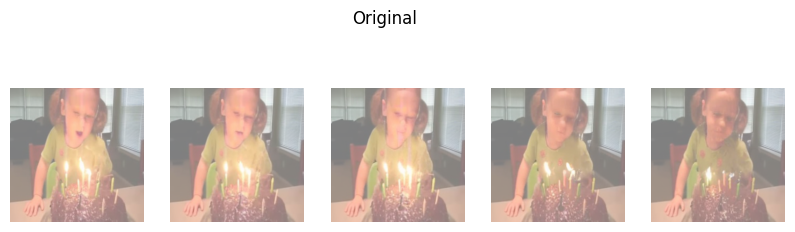

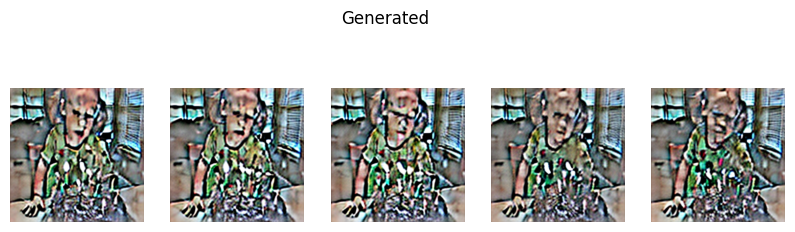

In [ ]:
# show original vs generated frames
import matplotlib.pyplot as plt

def show_frames(frames, title):
    plt.figure(figsize=(10,3))
    for i in range(min(5, len(frames))):
        plt.subplot(1,5,i+1)
        plt.imshow(frames[i])
        plt.axis("off")
    plt.suptitle(title)
    plt.show()
orig = (decode_latents(x0).permute(0,2,3,1).cpu().numpy())
show_frames(orig, "Original")
gen = (output_frames.permute(0,2,3,1).cpu().numpy())
show_frames(gen, "Generated")

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

video_path = "/v_BlowingCandles_g05_c05.avi"  # upload your video
frames = load_video(video_path)


x0 = encode_frames(frames)
x1 = x0 + 0.1 * torch.randn_like(x0)

for step in tqdm(range(1000)):
    loss = soft_sb_loss(model, x0, x1, "a person wearing a hat", 0.7)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

✅ Loaded 16 frames


  0%|          | 1/1000 [00:03<50:14,  3.02s/it]

Step 0, Loss: 0.8189


  5%|▌         | 51/1000 [01:53<35:18,  2.23s/it]

Step 50, Loss: 0.0995


...

 86%|████████▌ | 857/1000 [31:19<05:14,  2.20s/it]/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'AutoencoderKL' object attribute is deprecated. Please access '__iter__' over 'AutoencoderKL's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
 88%|████████▊ | 885/1000 [32:21<04:14,  2.21s/it]/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'AutoencoderKL' object attribute is deprecated. Please access '__iter__' over 'AutoencoderKL's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
 90%|█████████ | 901/1000 [32:56<03:40,  2.22s/it]

Step 900, Loss: 0.0128


 95%|█████████▌| 951/1000 [34:45<01:48,  2.21s/it]

Step 950, Loss: 0.0125


100%|██████████| 1000/1000 [36:33<00:00,  2.19s/it]


In [ ]:
import torch

# Save the model weights to a file
model_path = 'drift_net_weights.pth'
torch.save(model.state_dict(), model_path)
print(f"✅ Model weights saved to {model_path}")

# Optionally download it to your local machine
from google.colab import files # type: ignore
files.download(model_path)

✅ Model weights saved to drift_net_weights.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>